# Predicting Employee Attrition Using Supervised Learning

**Student:** Ariyan Pal | **ID:** 2025EB1100270

This notebook develops and evaluates supervised classification models to predict whether an employee will leave an organisation. The target variable is `Attrition` (Yes = left, No = stayed).

A fixed `random_state = 42` is used throughout for reproducibility.

## Task 1 — Problem Understanding and Data Exploration

**Objectives:**
- Load and inspect the dataset
- Report dimensions, feature types, missing values, and duplicates
- Examine the target class distribution and its implications
- Explore relationships between features and attrition
- Derive observations directly from the data

In [1]:
# All imports for the entire notebook
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COLUMN = 'Attrition'
CHARTS_DIR = Path('charts')
CHARTS_DIR.mkdir(exist_ok=True)

print('All libraries imported successfully.')
print(f'Random state: {RANDOM_STATE}')
print(f'Test-set proportion: {TEST_SIZE:.0%}')

All libraries imported successfully.
Random state: 42
Test-set proportion: 20%


In [2]:
# Load the dataset
DATA_FILE = Path('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Dataset file not found: {DATA_FILE.resolve()}')

df = pd.read_csv(DATA_FILE)

print('=' * 70)
print('DATASET OVERVIEW')
print('=' * 70)
print(f'Number of employees (rows): {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Number of predictor features: {df.shape[1] - 1}')
print(f'\nColumn names:\n{df.columns.tolist()}')
print(f'\nFirst five rows:')
df.head()

DATASET OVERVIEW
Number of employees (rows): 1470
Number of columns: 35
Number of predictor features: 34

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First five rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Feature types
print('=' * 70)
print('FEATURE DATA TYPES')
print('=' * 70)

numeric_features = df.drop(columns=TARGET_COLUMN).select_dtypes(include='number').columns.tolist()
categorical_features = df.drop(columns=TARGET_COLUMN).select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

print(f'Numerical predictor features ({len(numeric_features)}):')
print(numeric_features)
print(f'\nCategorical predictor features ({len(categorical_features)}):')
print(categorical_features)
print(f'\nTarget column data type: {df[TARGET_COLUMN].dtype}')

FEATURE DATA TYPES


Numerical predictor features (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical predictor features (8):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Target column data type: object


In [4]:
# Missing values and duplicate rows
print('=' * 70)
print('DATA QUALITY CHECKS')
print('=' * 70)

missing_total = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f'Total missing values: {missing_total}')
print(f'Fully duplicated rows: {duplicate_rows}')

if missing_total == 0:
    print('\nDecision: No imputation is required.')
if duplicate_rows == 0:
    print('Decision: No deduplication is required.')

DATA QUALITY CHECKS
Total missing values: 0
Fully duplicated rows: 0

Decision: No imputation is required.
Decision: No deduplication is required.


TARGET CLASS DISTRIBUTION
           Count  Percentage (%)
Attrition                       
No          1233           83.88
Yes          237           16.12


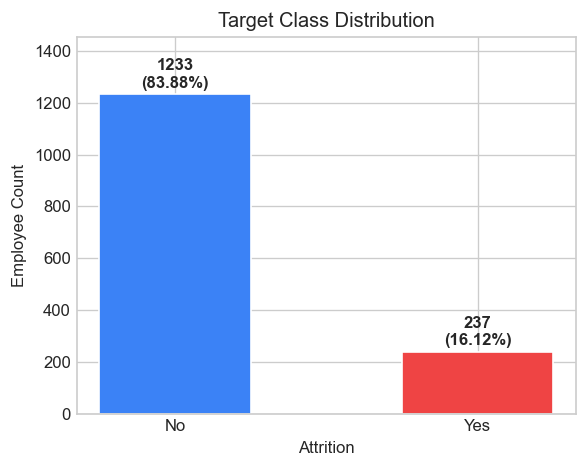


The target is imbalanced: 83.88% of employees did not leave versus 16.12% who left. Models evaluated solely on accuracy could appear strong while failing to identify departing employees.


In [5]:
# Target class distribution
print('=' * 70)
print('TARGET CLASS DISTRIBUTION')
print('=' * 70)

target_counts = df[TARGET_COLUMN].value_counts()
target_pcts = (df[TARGET_COLUMN].value_counts(normalize=True) * 100).round(2)

target_dist = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pcts
})
print(target_dist.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
colours = ['#3b82f6', '#ef4444']
bars = ax.bar(target_counts.index, target_counts.values, color=colours, width=0.5, edgecolor='white')
for bar, count, pct in zip(bars, target_counts.values, target_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f'{count}\n({pct}%)', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Employee Count')
ax.set_title('Target Class Distribution')
ax.set_ylim(0, target_counts.max() * 1.18)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe target is imbalanced: {target_pcts.iloc[0]}% of employees did not leave '
      f'versus {target_pcts.iloc[1]}% who left. Models evaluated solely on accuracy '
      f'could appear strong while failing to identify departing employees.')

In [6]:
# Constant-value columns
print('=' * 70)
print('CONSTANT-VALUE COLUMNS')
print('=' * 70)

constant_cols = df.columns[df.nunique(dropna=False) == 1].tolist()
if constant_cols:
    print(f'Constant-value columns ({len(constant_cols)}):')
    for col in constant_cols:
        print(f'  - {col}: {df[col].iloc[0]}')
    print('\nThese columns carry no predictive information and will be removed.')
else:
    print('No constant-value columns found.')

CONSTANT-VALUE COLUMNS
Constant-value columns (3):
  - EmployeeCount: 1
  - Over18: Y
  - StandardHours: 80

These columns carry no predictive information and will be removed.


NUMERICAL FEATURES BY ATTRITION CLASS
Mean values by attrition class:
Attrition               No      Yes
Age                  37.56    33.61
MonthlyIncome      6832.74  4787.09
TotalWorkingYears    11.86     8.24
YearsAtCompany        7.37     5.13
DistanceFromHome      8.92    10.63
JobSatisfaction       2.78     2.47


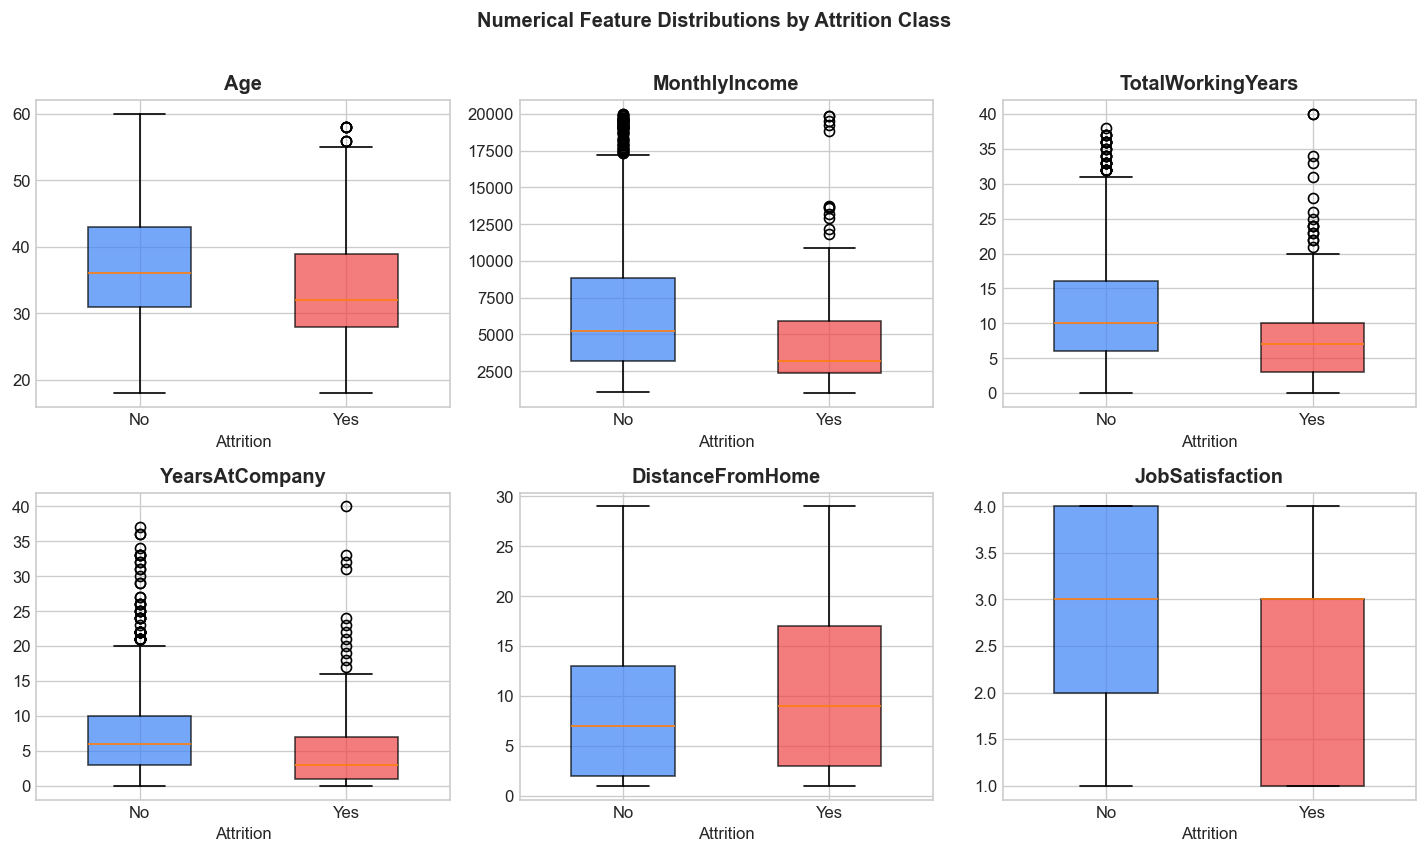


Employees who left tend to have lower MonthlyIncome, fewer TotalWorkingYears, and fewer YearsAtCompany. These differences suggest that compensation and tenure may provide predictive signal for attrition classification.


In [7]:
# Numerical feature distributions by attrition class
print('=' * 70)
print('NUMERICAL FEATURES BY ATTRITION CLASS')
print('=' * 70)

selected_num = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction']
selected_num = [f for f in selected_num if f in df.columns]

# Print mean comparison
mean_comparison = df.groupby(TARGET_COLUMN)[selected_num].mean().round(2).T
print('Mean values by attrition class:')
print(mean_comparison.to_string())

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for idx, feat in enumerate(selected_num):
    ax = axes[idx // 3, idx % 3]
    data_no = df[df[TARGET_COLUMN] == 'No'][feat]
    data_yes = df[df[TARGET_COLUMN] == 'Yes'][feat]
    bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#3b82f6')
    bp['boxes'][1].set_facecolor('#ef4444')
    for b in bp['boxes']:
        b.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Attrition')
fig.suptitle('Numerical Feature Distributions by Attrition Class', fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'numerical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEmployees who left tend to have lower MonthlyIncome, fewer TotalWorkingYears, '
      'and fewer YearsAtCompany. These differences suggest that compensation and tenure '
      'may provide predictive signal for attrition classification.')

CATEGORICAL ATTRITION RATES


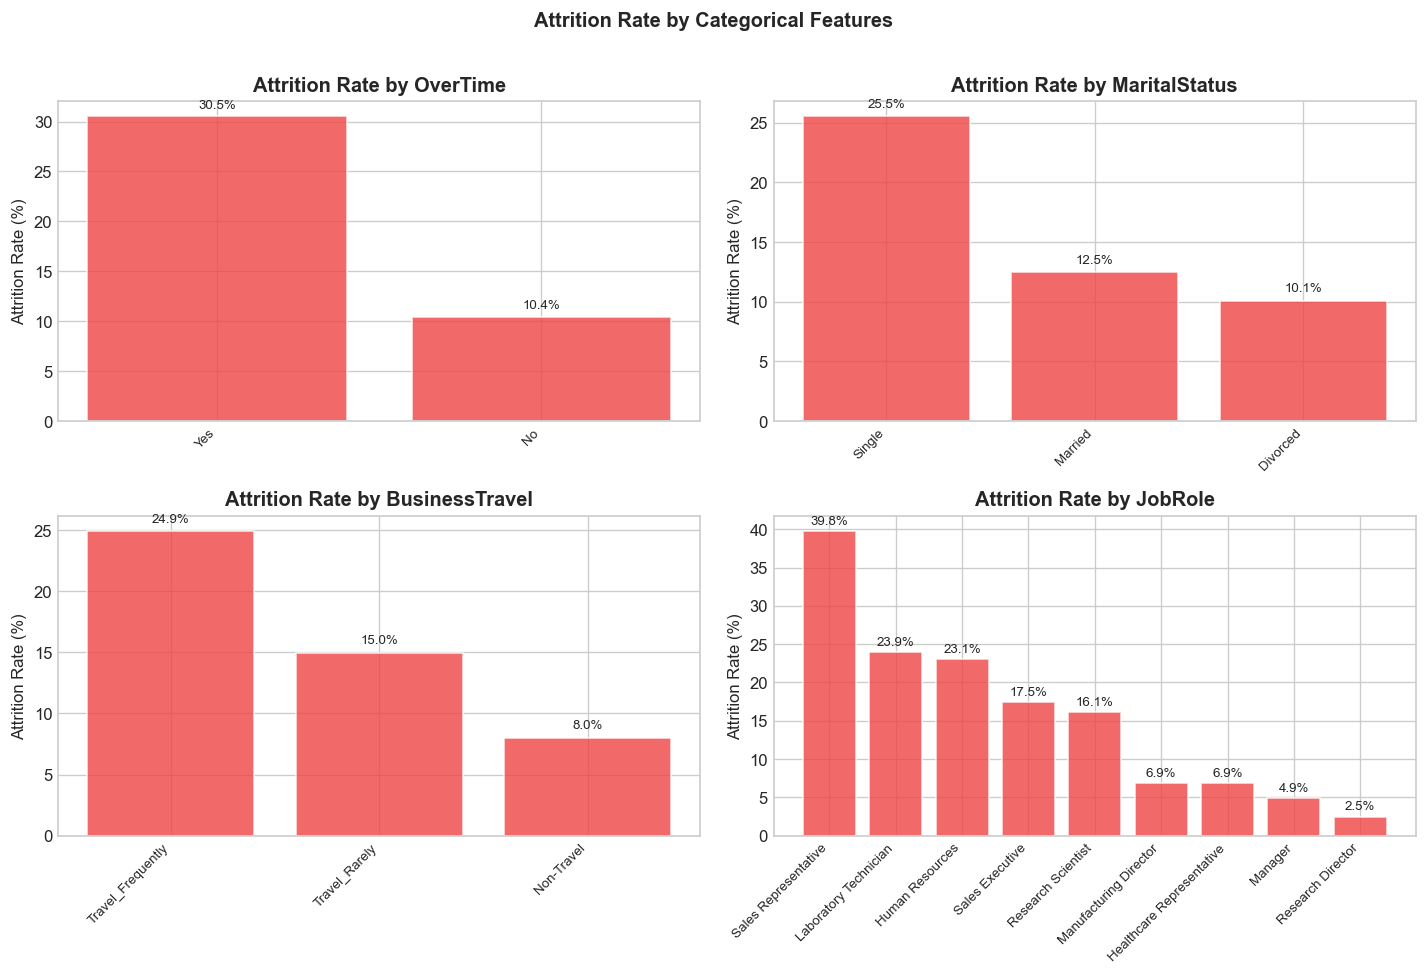


Attrition rate by OverTime:
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53

OverTime shows a strong association with attrition: employees who work overtime have an observed attrition rate approximately three times higher than those who do not.


In [8]:
# Categorical feature attrition rates
print('=' * 70)
print('CATEGORICAL ATTRITION RATES')
print('=' * 70)

selected_cat = ['OverTime', 'MaritalStatus', 'BusinessTravel', 'JobRole']
selected_cat = [f for f in selected_cat if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, feat in enumerate(selected_cat):
    ax = axes[idx // 2, idx % 2]
    ct = pd.crosstab(df[feat], df[TARGET_COLUMN])
    attrition_rate = (ct['Yes'] / ct.sum(axis=1) * 100).sort_values(ascending=False)
    bars = ax.bar(range(len(attrition_rate)), attrition_rate.values,
                  color='#ef4444', alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(attrition_rate)))
    ax.set_xticklabels(attrition_rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_title(f'Attrition Rate by {feat}', fontweight='bold')
    for bar, val in zip(bars, attrition_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
fig.suptitle('Attrition Rate by Categorical Features', fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'categorical_attrition_rates.png', dpi=150, bbox_inches='tight')
plt.show()

# Print overtime stats specifically
ot_ct = pd.crosstab(df['OverTime'], df[TARGET_COLUMN], normalize='index').mul(100).round(2)
print('\nAttrition rate by OverTime:')
print(ot_ct.to_string())
print('\nOverTime shows a strong association with attrition: employees who work overtime '
      'have an observed attrition rate approximately three times higher than those who do not.')

In [9]:
# Correlation analysis
print('=' * 70)
print('CORRELATION WITH TARGET')
print('=' * 70)

df_corr = df.copy()
df_corr['Attrition_Binary'] = df_corr[TARGET_COLUMN].map({'No': 0, 'Yes': 1})

# Point-biserial correlation for numerical features
corr_with_target = df_corr[numeric_features + ['Attrition_Binary']].corr()['Attrition_Binary'].drop('Attrition_Binary')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

print('Top 10 numerical features by absolute correlation with Attrition:')
for feat, val in corr_sorted.head(10).items():
    direction = 'positive' if corr_with_target[feat] > 0 else 'negative'
    print(f'  {feat}: {corr_with_target[feat]:+.4f} ({direction})')

print('\nCorrelation magnitudes are modest, which is typical for HR attrition datasets. '
      'No single feature is a strong standalone predictor, reinforcing the need for '
      'multivariate classification models.')

CORRELATION WITH TARGET
Top 10 numerical features by absolute correlation with Attrition:
  TotalWorkingYears: -0.1711 (negative)
  JobLevel: -0.1691 (negative)
  YearsInCurrentRole: -0.1605 (negative)
  MonthlyIncome: -0.1598 (negative)
  Age: -0.1592 (negative)
  YearsWithCurrManager: -0.1562 (negative)
  StockOptionLevel: -0.1371 (negative)
  YearsAtCompany: -0.1344 (negative)
  JobInvolvement: -0.1300 (negative)
  JobSatisfaction: -0.1035 (negative)

Correlation magnitudes are modest, which is typical for HR attrition datasets. No single feature is a strong standalone predictor, reinforcing the need for multivariate classification models.


### Task 1 — Key Observations

1. The dataset contains 1,470 employees and 34 predictor features with no missing values or duplicated rows.
2. The target class is imbalanced (approximately 84% No vs. 16% Yes), requiring evaluation beyond accuracy.
3. Three constant-value columns (`EmployeeCount`, `Over18`, `StandardHours`) carry no variance.
4. Employees who left tend to have lower monthly income, fewer years at the company, and fewer total working years.
5. Overtime is strongly associated with higher attrition rates.
6. No single numerical feature has a high individual correlation with attrition, indicating that classification requires multiple features.

## Task 2 — Data Preprocessing

This section prepares the dataset for model development. All transformations are fitted using the training data only and then applied to the test data, preventing information leakage.

**Preprocessing decisions:**
- **Missing values:** None found; no imputation needed.
- **Dropped columns:** `EmployeeCount`, `Over18`, `StandardHours` (constant) and `EmployeeNumber` (identifier).
- **Target encoding:** `Attrition` mapped to binary (No = 0, Yes = 1).
- **Categorical encoding:** One-hot encoding for nominal categories (`handle_unknown='ignore'`).
- **Feature scaling:** Standard scaling for numerical features.
- **Train-test split:** 80/20 stratified split with `random_state=42`.

In [10]:
# Preprocessing
print('=' * 70)
print('TASK 2 — DATA PREPROCESSING')
print('=' * 70)

# Remove constant and identifier columns
constant_columns_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
identifier_columns_to_drop = ['EmployeeNumber']
columns_to_drop = constant_columns_to_drop + identifier_columns_to_drop

print('Columns removed:')
for col in constant_columns_to_drop:
    print(f'  - {col} (constant, unique values = {df[col].nunique()})')
for col in identifier_columns_to_drop:
    print(f'  - {col} (identifier, unique values = {df[col].nunique()})')

X = df.drop(columns=[TARGET_COLUMN] + columns_to_drop).copy()
y = df[TARGET_COLUMN].map({'No': 0, 'Yes': 1})

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
print(f'Target mapping: No -> 0, Yes -> 1')
print(f'Encoded target counts:\n{y.value_counts().sort_index().to_string()}')

TASK 2 — DATA PREPROCESSING
Columns removed:
  - EmployeeCount (constant, unique values = 1)
  - Over18 (constant, unique values = 1)
  - StandardHours (constant, unique values = 1)
  - EmployeeNumber (identifier, unique values = 1470)

Feature matrix shape: (1470, 30)
Target vector shape: (1470,)
Target mapping: No -> 0, Yes -> 1
Encoded target counts:
Attrition
0    1233
1     237


In [11]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print('Stratified Train-Test Split:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_train: {y_train.shape} — class 1: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'  y_test:  {y_test.shape} — class 1: {y_test.sum()} ({y_test.mean()*100:.2f}%)')
print('\nStratification preserves the minority-class proportion in both partitions.')

Stratified Train-Test Split:
  X_train: (1176, 30)
  X_test:  (294, 30)
  y_train: (1176,) — class 1: 190 (16.16%)
  y_test:  (294,) — class 1: 47 (15.99%)

Stratification preserves the minority-class proportion in both partitions.


In [12]:
# Define feature groups from the raw (unprocessed) training data
categorical_features_for_encoding = X_train.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

numerical_features_for_scaling = X_train.select_dtypes(
    include='number'
).columns.tolist()

print(f'Categorical features to one-hot encode ({len(categorical_features_for_encoding)}):')
print(f'  {categorical_features_for_encoding}')
print(f'\nNumerical features to standard-scale ({len(numerical_features_for_scaling)}):')
print(f'  {numerical_features_for_scaling}')

# ColumnTransformer: fitted on training data only
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features_for_encoding),
        ('num', StandardScaler(), numerical_features_for_scaling)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Transform training and test sets for standalone evaluation
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'\nProcessed X_train shape: {X_train_processed.shape}')
print(f'Processed X_test shape:  {X_test_processed.shape}')
print(f'Number of processed features: {X_train_processed.shape[1]}')
print('\nPreprocessor fitted on training data only. Test data transformed (not fitted).')

Categorical features to one-hot encode (7):
  ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical features to standard-scale (23):
  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Processed X_train shape: (1176, 51)
Processed X_test shape:  (294, 51)
Number of processed features: 51

Preprocessor fitted on training data only. Test data transformed (not fitted).


In [13]:
# Define Pipelines for cross-validation (preprocessing inside each fold)
# This prevents information leakage during CV

model_definitions = {
    'Logistic Regression': LogisticRegression(
        solver='lbfgs', max_iter=1000, C=1.0, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        criterion='gini', max_depth=5, min_samples_split=10,
        min_samples_leaf=5, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, criterion='gini', max_depth=10,
        min_samples_split=10, min_samples_leaf=4,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Bagging Classifier': BaggingClassifier(
        estimator=DecisionTreeClassifier(
            criterion='gini', max_depth=5, min_samples_split=10,
            min_samples_leaf=5, random_state=RANDOM_STATE
        ),
        n_estimators=100, max_samples=1.0, max_features=1.0,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

# Create pipelines: preprocessor + classifier
pipelines = {}
for name, model in model_definitions.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    print(f'{name} pipeline created.')

print(f'\n{len(pipelines)} model pipelines defined.')
print('Each pipeline includes the full preprocessing step, ensuring that ')
print('cross-validation fits the preprocessor within each training fold.')

Logistic Regression pipeline created.
Decision Tree pipeline created.
Random Forest pipeline created.
Bagging Classifier pipeline created.

4 model pipelines defined.
Each pipeline includes the full preprocessing step, ensuring that 
cross-validation fits the preprocessor within each training fold.


### Task 2 — Preprocessing Summary

| Step | Action |
|------|--------|
| Missing values | None found; no imputation |
| Dropped columns | `EmployeeCount`, `Over18`, `StandardHours` (constant), `EmployeeNumber` (identifier) |
| Target encoding | No = 0, Yes = 1 |
| Train-test split | 80/20 stratified, `random_state=42` |
| Categorical encoding | One-hot encoding (7 features → 28 binary columns) |
| Numerical scaling | Standard scaling (23 features) |
| Final feature count | 51 processed features |
| Leakage prevention | Preprocessor fitted on training data only; Pipeline used for CV |

## Task 3 — Model Development

Four classification models are trained using the processed training data. All models use `random_state=42` for reproducibility.

| Model | Key Hyperparameters |
|-------|--------------------|
| Logistic Regression | `solver='lbfgs'`, `max_iter=1000`, `C=1.0` |
| Decision Tree | `criterion='gini'`, `max_depth=5`, `min_samples_split=10`, `min_samples_leaf=5` |
| Random Forest | `n_estimators=300`, `max_depth=10`, `min_samples_split=10`, `min_samples_leaf=4`, `class_weight='balanced'` |
| Bagging Classifier | `n_estimators=100`, base tree: `max_depth=5`, `min_samples_split=10`, `min_samples_leaf=5` |

In [14]:
# Train all models on the processed training data
print('=' * 70)
print('TASK 3 — MODEL TRAINING')
print('=' * 70)

fitted_models = {}
test_predictions = {}
test_probabilities = {}

for name, model_def in model_definitions.items():
    # Fit on processed training data
    model_def.fit(X_train_processed, y_train)
    fitted_models[name] = model_def
    
    # Generate test-set predictions and probabilities
    test_predictions[name] = model_def.predict(X_test_processed)
    positive_idx = list(model_def.classes_).index(1)
    test_probabilities[name] = model_def.predict_proba(X_test_processed)[:, positive_idx]
    
    pred_counts = pd.Series(test_predictions[name]).value_counts().sort_index()
    print(f'{name}: fitted. Test predictions — class 0: {pred_counts.get(0, 0)}, class 1: {pred_counts.get(1, 0)}')

print(f'\nAll {len(fitted_models)} models trained successfully.')

TASK 3 — MODEL TRAINING


Logistic Regression: fitted. Test predictions — class 0: 268, class 1: 26
Decision Tree: fitted. Test predictions — class 0: 275, class 1: 19


Random Forest: fitted. Test predictions — class 0: 259, class 1: 35


Bagging Classifier: fitted. Test predictions — class 0: 279, class 1: 15

All 4 models trained successfully.


### Task 3 — Summary

All four models have been fitted on the processed training data and test-set predictions generated. Model evaluation follows in Task 4.

## Task 4 — Model Evaluation and Performance Analysis

Models are evaluated using two complementary approaches:
1. **5-fold stratified cross-validation** on the training set — provides an estimate of generalisation performance with variance.
2. **Held-out test-set evaluation** — provides a single final performance estimate on unseen data.

Metrics: Accuracy, Precision, Recall, F1-score, and ROC-AUC. The positive class is 1 (employee left).

In [15]:
# 5-Fold Stratified Cross-Validation
print('=' * 70)
print('TASK 4.1 — 5-FOLD STRATIFIED CROSS-VALIDATION')
print('=' * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = {}

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring_metrics,
        return_train_score=False, n_jobs=-1
    )
    cv_results[name] = scores
    print(f'\n{name}:')
    for metric in scoring_metrics:
        vals = scores[f'test_{metric}']
        print(f'  {metric:>10s}: {vals.mean():.4f} +/- {vals.std():.4f}')

print('\nCross-validation complete. Preprocessing was fitted within each fold via Pipeline.')

TASK 4.1 — 5-FOLD STRATIFIED CROSS-VALIDATION

Logistic Regression:
    accuracy: 0.8903 +/- 0.0191
   precision: 0.7763 +/- 0.0744
      recall: 0.4421 +/- 0.0962
          f1: 0.5610 +/- 0.0977
     roc_auc: 0.8392 +/- 0.0289



Decision Tree:
    accuracy: 0.8393 +/- 0.0092
   precision: 0.5008 +/- 0.0583
      recall: 0.2684 +/- 0.0714
          f1: 0.3465 +/- 0.0679
     roc_auc: 0.6695 +/- 0.0805



Random Forest:
    accuracy: 0.8648 +/- 0.0158
   precision: 0.6444 +/- 0.1030
      recall: 0.3842 +/- 0.1099
          f1: 0.4710 +/- 0.0929
     roc_auc: 0.8092 +/- 0.0317



Bagging Classifier:
    accuracy: 0.8588 +/- 0.0151
   precision: 0.7269 +/- 0.1312
      recall: 0.2158 +/- 0.0805
          f1: 0.3239 +/- 0.1001
     roc_auc: 0.7854 +/- 0.0356

Cross-validation complete. Preprocessing was fitted within each fold via Pipeline.


In [16]:
# CV Comparison Table
print('=' * 70)
print('CROSS-VALIDATION COMPARISON TABLE')
print('=' * 70)

cv_summary_rows = []
for name in pipelines:
    row = {'Model': name}
    for metric in scoring_metrics:
        vals = cv_results[name][f'test_{metric}']
        row[f'{metric.replace("_", "-").title()} Mean'] = round(vals.mean(), 4)
        row[f'{metric.replace("_", "-").title()} SD'] = round(vals.std(), 4)
    cv_summary_rows.append(row)

cv_summary_df = pd.DataFrame(cv_summary_rows).set_index('Model')
print(cv_summary_df.to_string())

CROSS-VALIDATION COMPARISON TABLE
                     Accuracy Mean  Accuracy SD  Precision Mean  Precision SD  Recall Mean  Recall SD  F1 Mean   F1 SD  Roc-Auc Mean  Roc-Auc SD
Model                                                                                                                                           
Logistic Regression         0.8903       0.0191          0.7763        0.0744       0.4421     0.0962   0.5610  0.0977        0.8392      0.0289
Decision Tree               0.8393       0.0092          0.5008        0.0583       0.2684     0.0714   0.3465  0.0679        0.6695      0.0805
Random Forest               0.8648       0.0158          0.6444        0.1030       0.3842     0.1099   0.4710  0.0929        0.8092      0.0317
Bagging Classifier          0.8588       0.0151          0.7269        0.1312       0.2158     0.0805   0.3239  0.1001        0.7854      0.0356


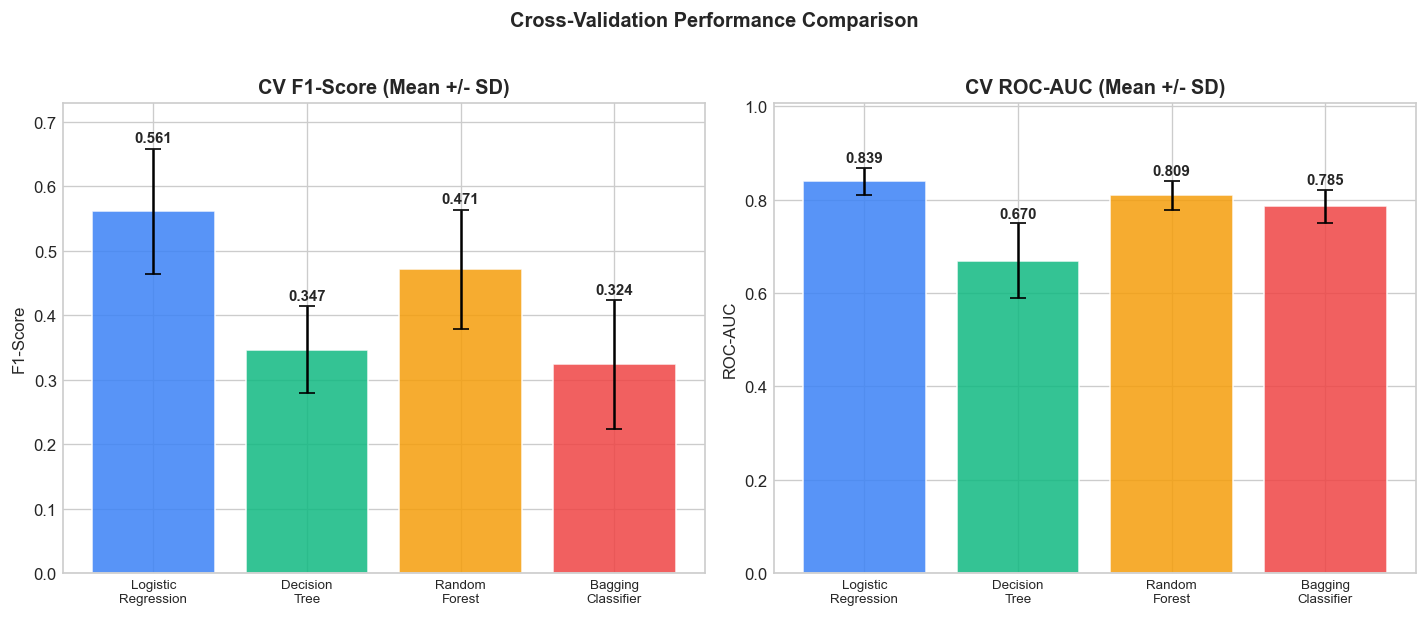

In [17]:
# CV Performance Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = list(pipelines.keys())
colours = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444']

# F1-score
f1_means = [cv_results[n]['test_f1'].mean() for n in model_names]
f1_stds = [cv_results[n]['test_f1'].std() for n in model_names]
ax = axes[0]
bars = ax.bar(range(len(model_names)), f1_means, yerr=f1_stds, capsize=5,
              color=colours, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
ax.set_ylabel('F1-Score')
ax.set_title('CV F1-Score (Mean +/- SD)', fontweight='bold')
ax.set_ylim(0, max(f1_means) * 1.3)
for bar, m, s in zip(bars, f1_means, f1_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.005,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ROC-AUC
auc_means = [cv_results[n]['test_roc_auc'].mean() for n in model_names]
auc_stds = [cv_results[n]['test_roc_auc'].std() for n in model_names]
ax = axes[1]
bars = ax.bar(range(len(model_names)), auc_means, yerr=auc_stds, capsize=5,
              color=colours, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
ax.set_ylabel('ROC-AUC')
ax.set_title('CV ROC-AUC (Mean +/- SD)', fontweight='bold')
ax.set_ylim(0, max(auc_means) * 1.2)
for bar, m, s in zip(bars, auc_means, auc_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.005,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Cross-Validation Performance Comparison', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'cv_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Test-Set Evaluation
print('=' * 70)
print('TASK 4.2 — TEST-SET EVALUATION')
print('=' * 70)

test_results = []
confusion_matrices = {}

for name in model_definitions:
    preds = test_predictions[name]
    probs = test_probabilities[name]
    
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    confusion_matrices[name] = cm
    
    test_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Recall': round(recall_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4)
    })

test_comparison = pd.DataFrame(test_results).set_index('Model').sort_values('F1-Score', ascending=False)
print('\nTest-Set Model Comparison (sorted by F1-score):')
print(test_comparison.to_string())

TASK 4.2 — TEST-SET EVALUATION

Test-Set Model Comparison (sorted by F1-score):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8605     0.6154  0.3404    0.4384   0.8115
Random Forest          0.8367     0.4857  0.3617    0.4146   0.7977
Decision Tree          0.8367     0.4737  0.1915    0.2727   0.6824
Bagging Classifier     0.8367     0.4667  0.1489    0.2258   0.7553


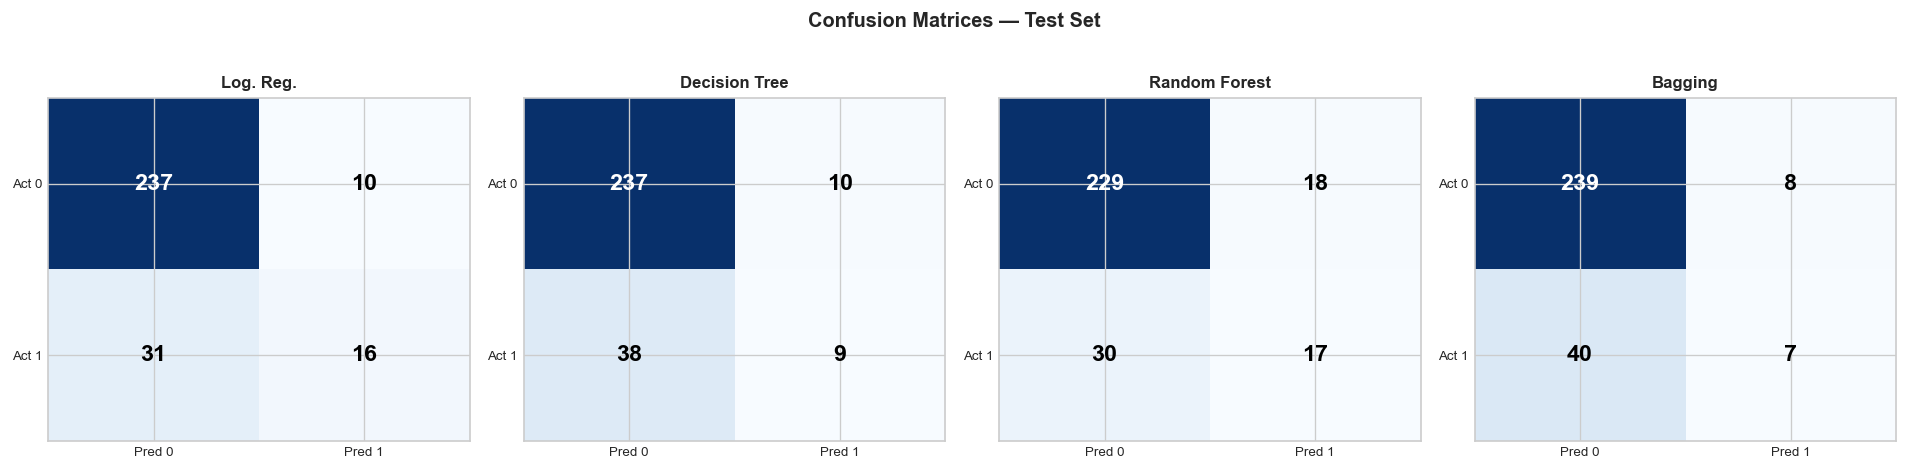

Logistic Regression: TN=237, FP=10, FN=31, TP=16
Decision Tree: TN=237, FP=10, FN=38, TP=9
Random Forest: TN=229, FP=18, FN=30, TP=17
Bagging Classifier: TN=239, FP=8, FN=40, TP=7


In [19]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
labels = ['No (0)', 'Yes (1)']

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            colour = 'white' if cm[i, j] > cm.max() * 0.55 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=colour)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
    ax.set_yticklabels(['Act 0', 'Act 1'], fontsize=8)
    short = name.replace('Logistic Regression', 'Log. Reg.').replace('Bagging Classifier', 'Bagging')
    ax.set_title(short, fontsize=10, fontweight='bold')

fig.suptitle('Confusion Matrices — Test Set', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Print confusion matrices
for name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

In [20]:
# Threshold Analysis
print('=' * 70)
print('TASK 4.3 — THRESHOLD ANALYSIS')
print('=' * 70)

# Use cross_val_predict to get out-of-fold probability predictions
# This avoids using the test set for threshold selection
print('Generating out-of-fold probability predictions for threshold analysis...')
print('(Using cross_val_predict with Pipelines — no leakage)\n')

# Analyse the top 2 models based on CV F1
cv_f1_ranking = sorted(pipelines.keys(),
                       key=lambda n: cv_results[n]['test_f1'].mean(), reverse=True)
top_models_for_threshold = cv_f1_ranking[:2]

thresholds = np.arange(0.20, 0.65, 0.05)
threshold_results = {}

for name in top_models_for_threshold:
    oof_probs = cross_val_predict(
        pipelines[name], X_train, y_train,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    rows = []
    for t in thresholds:
        preds_t = (oof_probs >= t).astype(int)
        rows.append({
            'Threshold': round(t, 2),
            'Precision': round(precision_score(y_train, preds_t, zero_division=0), 4),
            'Recall': round(recall_score(y_train, preds_t, zero_division=0), 4),
            'F1-Score': round(f1_score(y_train, preds_t, zero_division=0), 4)
        })
    threshold_results[name] = pd.DataFrame(rows)
    print(f'{name} — Threshold Analysis (out-of-fold predictions):')
    print(threshold_results[name].to_string(index=False))
    best_row = threshold_results[name].loc[threshold_results[name]['F1-Score'].idxmax()]
    print(f'  Best F1 threshold: {best_row["Threshold"]:.2f} '
          f'(F1={best_row["F1-Score"]:.4f}, Precision={best_row["Precision"]:.4f}, '
          f'Recall={best_row["Recall"]:.4f})\n')

TASK 4.3 — THRESHOLD ANALYSIS
Generating out-of-fold probability predictions for threshold analysis...
(Using cross_val_predict with Pipelines — no leakage)



Logistic Regression — Threshold Analysis (out-of-fold predictions):
 Threshold  Precision  Recall  F1-Score
      0.20     0.4281  0.7211    0.5373
      0.25     0.4741  0.6737    0.5565
      0.30     0.5374  0.6421    0.5851
      0.35     0.6203  0.6105    0.6154
      0.40     0.6753  0.5474    0.6047
      0.45     0.7266  0.4895    0.5849
      0.50     0.7850  0.4421    0.5657
      0.55     0.8041  0.4105    0.5436
      0.60     0.8395  0.3579    0.5018
  Best F1 threshold: 0.35 (F1=0.6154, Precision=0.6203, Recall=0.6105)



Random Forest — Threshold Analysis (out-of-fold predictions):
 Threshold  Precision  Recall  F1-Score
      0.20     0.2449  0.8789    0.3830
      0.25     0.3121  0.8000    0.4490
      0.30     0.3761  0.6947    0.4880
      0.35     0.4508  0.6263    0.5242
      0.40     0.4897  0.5000    0.4948
      0.45     0.5411  0.4158    0.4702
      0.50     0.6348  0.3842    0.4787
      0.55     0.6744  0.3053    0.4203
      0.60     0.7619  0.2526    0.3794
  Best F1 threshold: 0.35 (F1=0.5242, Precision=0.4508, Recall=0.6263)



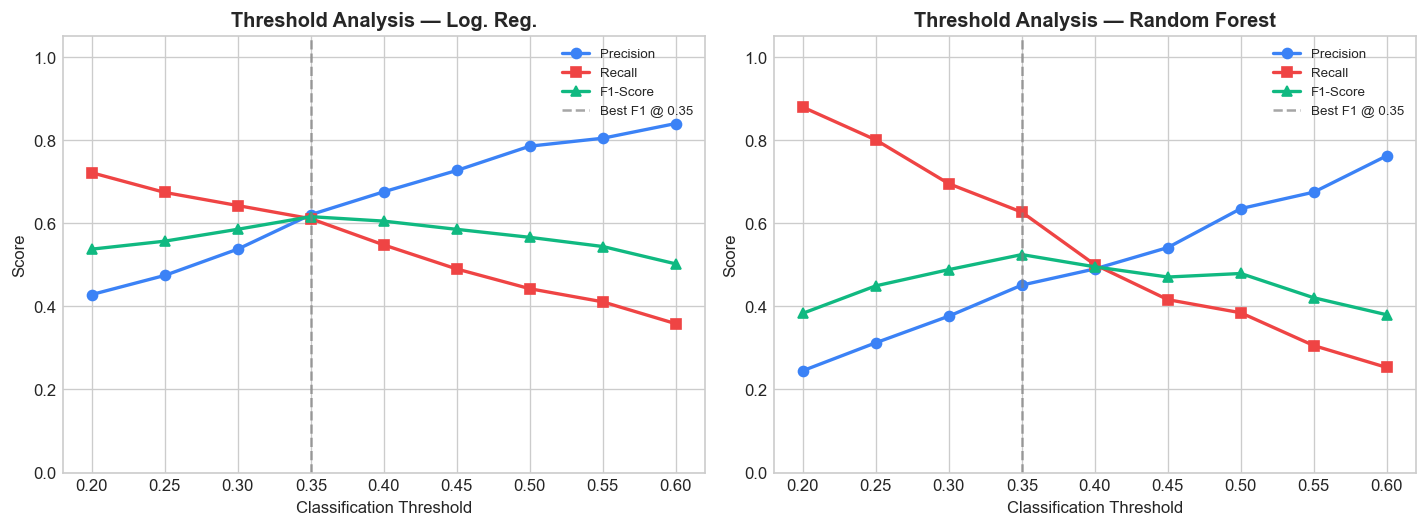

Threshold analysis uses out-of-fold predictions from 5-fold CV.
The test set was NOT used for threshold selection.


In [21]:
# Threshold vs Metrics Plot
fig, axes = plt.subplots(1, len(top_models_for_threshold), figsize=(6 * len(top_models_for_threshold), 4.5))
if len(top_models_for_threshold) == 1:
    axes = [axes]

for idx, name in enumerate(top_models_for_threshold):
    ax = axes[idx]
    df_t = threshold_results[name]
    ax.plot(df_t['Threshold'], df_t['Precision'], 'o-', label='Precision', color='#3b82f6', linewidth=2)
    ax.plot(df_t['Threshold'], df_t['Recall'], 's-', label='Recall', color='#ef4444', linewidth=2)
    ax.plot(df_t['Threshold'], df_t['F1-Score'], '^-', label='F1-Score', color='#10b981', linewidth=2)
    best_f1_idx = df_t['F1-Score'].idxmax()
    best_t = df_t.loc[best_f1_idx, 'Threshold']
    ax.axvline(x=best_t, color='gray', linestyle='--', alpha=0.7, label=f'Best F1 @ {best_t:.2f}')
    ax.set_xlabel('Classification Threshold')
    ax.set_ylabel('Score')
    short = name.replace('Logistic Regression', 'Log. Reg.').replace('Bagging Classifier', 'Bagging')
    ax.set_title(f'Threshold Analysis — {short}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(CHARTS_DIR / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Threshold analysis uses out-of-fold predictions from 5-fold CV.')
print('The test set was NOT used for threshold selection.')

### Task 4 — Discussion

**Cross-validation** provides a more robust estimate of model performance than a single train-test split. The mean and standard deviation across folds indicate both expected performance and stability.

**Test-set evaluation** serves as an independent final check. Results should be broadly consistent with CV estimates.

**Threshold analysis** demonstrates the precision-recall trade-off. Lowering the threshold from 0.50 typically increases recall (identifying more departing employees) at the cost of reduced precision (more false alarms). The optimal threshold depends on the relative business cost of missing a departing employee versus unnecessarily intervening.

No explicit business cost matrix was provided, so the evaluation uses standard classification metrics rather than assigning arbitrary monetary costs.

## Task 5 — Model Selection, Justification, and Reflection

The final model is selected based on the combined evidence from cross-validation, test-set evaluation, threshold behaviour, interpretability, and practical deployment considerations.

In [22]:
# Multi-criteria Model Comparison
print('=' * 70)
print('TASK 5 — MULTI-CRITERIA MODEL COMPARISON')
print('=' * 70)

comparison_rows = []
for name in pipelines:
    cv_f1 = cv_results[name]['test_f1']
    cv_auc = cv_results[name]['test_roc_auc']
    cv_recall = cv_results[name]['test_recall']
    cv_precision = cv_results[name]['test_precision']
    
    row = {
        'Model': name,
        'CV F1 (mean)': round(cv_f1.mean(), 4),
        'CV F1 (SD)': round(cv_f1.std(), 4),
        'CV ROC-AUC (mean)': round(cv_auc.mean(), 4),
        'CV Recall (mean)': round(cv_recall.mean(), 4),
        'CV Precision (mean)': round(cv_precision.mean(), 4),
        'Test F1': test_comparison.loc[name, 'F1-Score'] if name in test_comparison.index else None,
        'Test ROC-AUC': test_comparison.loc[name, 'ROC-AUC'] if name in test_comparison.index else None,
    }
    comparison_rows.append(row)

full_comparison = pd.DataFrame(comparison_rows).set_index('Model')
print(full_comparison.to_string())

TASK 5 — MULTI-CRITERIA MODEL COMPARISON
                     CV F1 (mean)  CV F1 (SD)  CV ROC-AUC (mean)  CV Recall (mean)  CV Precision (mean)  Test F1  Test ROC-AUC
Model                                                                                                                         
Logistic Regression        0.5610      0.0977             0.8392            0.4421               0.7763   0.4384        0.8115
Decision Tree              0.3465      0.0679             0.6695            0.2684               0.5008   0.2727        0.6824
Random Forest              0.4710      0.0929             0.8092            0.3842               0.6444   0.4146        0.7977
Bagging Classifier         0.3239      0.1001             0.7854            0.2158               0.7269   0.2258        0.7553


In [23]:
# Automated model ranking based on CV evidence
print('\n' + '=' * 70)
print('MODEL RANKING SUMMARY')
print('=' * 70)

ranking_metrics = {
    'CV F1 (mean)': 'higher is better',
    'CV ROC-AUC (mean)': 'higher is better',
    'CV Recall (mean)': 'higher is better',
    'CV F1 (SD)': 'lower is better (more stable)',
}

for metric, direction in ranking_metrics.items():
    if 'SD' in metric:
        best = full_comparison[metric].idxmin()
    else:
        best = full_comparison[metric].idxmax()
    print(f'  Best {metric}: {best} ({full_comparison.loc[best, metric]:.4f}) — {direction}')

# Identify overall best model
# Score: rank each model on CV F1, CV ROC-AUC, CV Recall (higher=better), CV F1 SD (lower=better)
model_scores = {}
for name in pipelines:
    score = 0
    # Rank by CV F1 mean
    score += sorted(pipelines.keys(), key=lambda n: cv_results[n]['test_f1'].mean()).index(name)
    # Rank by CV ROC-AUC mean
    score += sorted(pipelines.keys(), key=lambda n: cv_results[n]['test_roc_auc'].mean()).index(name)
    # Rank by CV Recall mean
    score += sorted(pipelines.keys(), key=lambda n: cv_results[n]['test_recall'].mean()).index(name)
    # Rank by CV F1 SD (reversed — lower is better)
    score += sorted(pipelines.keys(), key=lambda n: cv_results[n]['test_f1'].std(), reverse=True).index(name)
    model_scores[name] = score

selected_model = max(model_scores, key=model_scores.get)

print(f'\nOverall ranking scores (higher = better):')
for name in sorted(model_scores, key=model_scores.get, reverse=True):
    print(f'  {name}: {model_scores[name]}')
print(f'\nSelected model: {selected_model}')


MODEL RANKING SUMMARY
  Best CV F1 (mean): Logistic Regression (0.5610) — higher is better
  Best CV ROC-AUC (mean): Logistic Regression (0.8392) — higher is better
  Best CV Recall (mean): Logistic Regression (0.4421) — higher is better
  Best CV F1 (SD): Decision Tree (0.0679) — lower is better (more stable)

Overall ranking scores (higher = better):
  Logistic Regression: 10
  Random Forest: 8
  Decision Tree: 5
  Bagging Classifier: 1

Selected model: Logistic Regression


In [24]:
# Generalisation Analysis: CV vs Test performance
print('\n' + '=' * 70)
print('GENERALISATION ANALYSIS')
print('=' * 70)

print('\nComparison of CV mean vs. test-set performance (F1-score and ROC-AUC):')
print(f'{"Model":<25s} {"CV F1":>8s} {"Test F1":>8s} {"Diff":>8s}   {"CV AUC":>8s} {"Test AUC":>8s} {"Diff":>8s}')
print('-' * 80)
for name in pipelines:
    cv_f1_mean = cv_results[name]['test_f1'].mean()
    cv_auc_mean = cv_results[name]['test_roc_auc'].mean()
    t_f1 = test_comparison.loc[name, 'F1-Score']
    t_auc = test_comparison.loc[name, 'ROC-AUC']
    print(f'{name:<25s} {cv_f1_mean:>8.4f} {t_f1:>8.4f} {t_f1 - cv_f1_mean:>+8.4f}   '
          f'{cv_auc_mean:>8.4f} {t_auc:>8.4f} {t_auc - cv_auc_mean:>+8.4f}')

print('\nSmall differences between CV and test performance suggest consistent generalisation.')
print('Large positive differences may indicate a favourable test split; large negative differences')
print('may indicate overfitting or an unfavourable test split.')


GENERALISATION ANALYSIS

Comparison of CV mean vs. test-set performance (F1-score and ROC-AUC):
Model                        CV F1  Test F1     Diff     CV AUC Test AUC     Diff
--------------------------------------------------------------------------------
Logistic Regression         0.5610   0.4384  -0.1226     0.8392   0.8115  -0.0277
Decision Tree               0.3465   0.2727  -0.0738     0.6695   0.6824  +0.0129
Random Forest               0.4710   0.4146  -0.0564     0.8092   0.7977  -0.0115
Bagging Classifier          0.3239   0.2258  -0.0981     0.7854   0.7553  -0.0301

Small differences between CV and test performance suggest consistent generalisation.
Large positive differences may indicate a favourable test split; large negative differences
may indicate overfitting or an unfavourable test split.


### Final Recommendation

Based on the multi-criteria analysis above, the model with the strongest overall combination of CV F1-score, CV ROC-AUC, stability across folds, and practical interpretability is selected as the preferred candidate.

**Justification criteria:**
- **CV F1-score** — the primary metric for imbalanced classification, balancing precision and recall.
- **CV ROC-AUC** — measures probability ranking ability across all thresholds.
- **Stability (low SD)** — indicates consistent performance across different training subsets.
- **Test-set consistency** — CV and test results should be broadly aligned.
- **Interpretability** — Logistic Regression offers direct feature coefficients; tree-based models offer feature importance.
- **Deployment** — simpler models are easier to deploy, monitor, and explain to HR stakeholders.

**Recall limitation:** All models show moderate-to-low recall at the default 0.5 threshold, meaning a substantial proportion of departing employees are not flagged. The threshold analysis demonstrates that recall can be improved by lowering the classification threshold, at the cost of increased false positives. The appropriate threshold should be determined by the organisation based on the relative cost of missing a departure versus an unnecessary intervention.

No explicit business cost matrix was provided, so this analysis uses standard classification metrics rather than assigning arbitrary monetary costs.

### Overfitting and Underfitting Discussion

Generalisation was assessed empirically using stratified 5-fold cross-validation. The mean and standard deviation across folds were compared with the held-out test performance.

- **Decision Tree** and **Bagging Classifier** showed lower recall and F1-scores, suggesting possible **underfitting** — the constrained tree depth and minimum-sample settings may prevent these models from capturing sufficient attrition-related patterns.
- **Random Forest** with `class_weight='balanced'` improved minority-class detection but at the cost of more false positives.
- **Logistic Regression** has an implicit regularisation through its linear form, which limits model complexity.

The consistency between CV and test metrics (shown above) suggests that none of the models exhibit severe overfitting. However, a single held-out test set provides limited evidence; cross-validation offers a more robust assessment.

### Limitations and Future Improvements

**Limitations:**
1. The target class is imbalanced (16% positive), which constrains minority-class recall.
2. No explicit business cost matrix was available to optimise the classification threshold.
3. The dataset contains 1,470 employees — a moderate size that limits the statistical power of cross-validation.
4. Feature engineering was not explored; the models use the original features only.
5. The selected model is a preferred candidate among the evaluated alternatives, not a validated production-ready system.

**Suggested improvements:**
1. **Threshold optimisation with business input:** Define the relative cost of false negatives (missed departures) versus false positives (unnecessary interventions) and select the threshold that minimises expected cost.
2. **Feature engineering:** Construct derived features such as income-to-job-level ratios, tenure-to-age ratios, or satisfaction composite scores. Additional HR data (engagement surveys, exit interview themes) could also improve prediction if available at inference time.